In [35]:
from google.colab import drive
drive.mount('/content/gdrive')
import warnings
warnings.filterwarnings('ignore')
!ls /content/gdrive/MyDrive/'Colab Notebooks'/'HOPE AI'/'WEEK-8.1_Adv_ML'/'capstone'
fileloc='/content/gdrive/MyDrive/Colab Notebooks/HOPE AI/WEEK-8.1_Adv_ML/capstone/'
import seaborn as sns
import scipy.stats as stats

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Algorithm.py		    Model.ipynb		steel_melting_data.csv
Bivariate_Steel.ipynb	    Preprocessed.ipynb	Univariate.py
Deployment.ipynb	    Prep_steel.csv	Univariate_Steel.ipynb
finalized_model_random.sav  __pycache__


In [36]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/content/gdrive/MyDrive/Colab Notebooks/HOPE AI/WEEK-8.1_Adv_ML/capstone')
from Univariate import Univariate

In [37]:
dataset = pd.read_csv(fileloc+"Prep_steel.csv")

In [38]:
dataset

,Furnace_Temperature,Carbon_Content,Silicon_Content,Manganese_Content,Sulfur_Content,Phosphorus_Content,Oxygen_Level,Power_Consumption,Melting_Time,Cooling_Time,Scrap_Weight,Flux_Added,Steel_Strength
0,1604.9,0.394,0.362,0.718,0.028,0.016,69.5,880.7,65.0,28.3,26.69,127.1,420.25
1,1592.2,0.371,0.109,0.758,0.040,0.030,37.5,858.6,65.3,40.7,30.15,295.5,416.32
2,1608.0,0.307,0.348,0.880,0.036,0.024,46.6,870.3,75.1,27.4,25.71,292.9,403.06
3,1625.5,0.496,0.139,0.813,0.035,0.036,21.3,1007.0,80.8,37.7,15.68,132.7,435.25
4,1590.3,0.382,0.201,1.136,0.024,0.016,38.1,766.6,62.8,27.5,34.59,159.9,430.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1605.8,0.404,0.208,1.061,0.012,0.023,30.2,853.1,93.4,28.7,31.57,177.9,423.87
496,1574.3,0.386,0.126,0.481,0.041,0.023,21.8,884.5,62.1,25.8,39.14,290.3,411.02
497,1591.2,0.426,0.381,0.592,0.027,0.029,32.3,855.6,70.4,25.4,37.90,163.9,432.93
498,1577.5,0.248,0.266,0.514,0.043,0.038,40.4,786.9,70.4,40.5,27.57,273.6,410.98


In [39]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Furnace_Temperature  500 non-null    float64
 1   Carbon_Content       500 non-null    float64
 2   Silicon_Content      500 non-null    float64
 3   Manganese_Content    500 non-null    float64
 4   Sulfur_Content       500 non-null    float64
 5   Phosphorus_Content   500 non-null    float64
 6   Oxygen_Level         500 non-null    float64
 7   Power_Consumption    500 non-null    float64
 8   Melting_Time         500 non-null    float64
 9   Cooling_Time         500 non-null    float64
 10  Scrap_Weight         500 non-null    float64
 11  Flux_Added           500 non-null    float64
 12  Steel_Strength       500 non-null    float64
dtypes: float64(13)
memory usage: 50.9 KB


In [40]:
quan,qual = Univariate.quanqual(dataset)

In [41]:
dataset.describe()

,Furnace_Temperature,Carbon_Content,Silicon_Content,Manganese_Content,Sulfur_Content,Phosphorus_Content,Oxygen_Level,Power_Consumption,Melting_Time,Cooling_Time,Scrap_Weight,Flux_Added,Steel_Strength
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.00000,500.000000,500.00000,500.000000
mean,1595.135800,0.350292,0.249870,0.801538,0.029946,0.025032,49.529800,849.670800,77.32440,34.88720,27.545460,198.71640,416.499020
std,19.625895,0.087263,0.087318,0.231910,0.011520,0.008762,17.071269,41.474607,10.10779,5.78913,7.239448,58.34761,15.602833
min,1530.200000,0.201000,0.101000,0.403000,0.010000,0.010000,20.000000,730.400000,60.00000,25.00000,15.150000,100.80000,362.660000
25%,1581.000000,0.270750,0.171000,0.596000,0.021000,0.018000,33.975000,820.675000,68.40000,29.77500,21.440000,146.85000,406.527500
50%,1595.300000,0.351500,0.255000,0.805000,0.030000,0.025000,49.400000,851.750000,77.20000,34.60000,27.585000,198.25000,416.750000
75%,1607.750000,0.427250,0.320250,1.009000,0.040000,0.032000,64.925000,878.825000,86.22500,40.00000,33.502500,251.82500,427.110000
max,1672.100000,0.499000,0.400000,1.199000,0.050000,0.040000,80.000000,1007.000000,94.90000,44.80000,39.980000,299.90000,458.840000


In [42]:
descriptive = Univariate.unidesc(dataset,quan)
descriptive

,Furnace_Temperature,Carbon_Content,Silicon_Content,Manganese_Content,Sulfur_Content,Phosphorus_Content,Oxygen_Level,Power_Consumption,Melting_Time,Cooling_Time,Scrap_Weight,Flux_Added,Steel_Strength
Mean,1595.1358,0.350292,0.24987,0.801538,0.029946,0.025032,49.5298,849.6708,77.3244,34.8872,27.54546,198.7164,416.49902
Median,1595.3,0.3515,0.255,0.805,0.03,0.025,49.4,851.75,77.2,34.6,27.585,198.25,416.75
Mode,1583.0,0.246,0.109,0.752,0.022,0.039,68.2,853.1,79.4,25.8,16.23,103.6,418.21
Q1:25%,1581.0,0.27075,0.171,0.596,0.021,0.018,33.975,820.675,68.4,29.775,21.44,146.85,406.5275
Q2:50%,1595.3,0.3515,0.255,0.805,0.03,0.025,49.4,851.75,77.2,34.6,27.585,198.25,416.75
Q3:75%,1607.75,0.42725,0.32025,1.009,0.04,0.032,64.925,878.825,86.225,40.0,33.5025,251.825,427.11
99%,1638.825,0.49601,0.39701,1.19301,0.04901,0.039,79.8,936.647,94.7,44.6,39.7603,297.303,452.7568
Q4:100%,1672.1,0.499,0.4,1.199,0.05,0.04,80.0,1007.0,94.9,44.8,39.98,299.9,458.84
IQR,26.75,0.1565,0.14925,0.413,0.019,0.014,30.95,58.15,17.825,10.225,12.0625,104.975,20.5825
1.5Rule,40.125,0.23475,0.223875,0.6195,0.0285,0.021,46.425,87.225,26.7375,15.3375,18.09375,157.4625,30.87375


In [43]:
lesser,greater = Univariate.findingoutlier(quan,descriptive)
print(lesser)
print(greater)

Lesser Outlier present in the column Furnace_Temperature
Greater Outlier present in the column Furnace_Temperature
Lesser Outlier present in the column Power_Consumption
Greater Outlier present in the column Power_Consumption
Lesser Outlier present in the column Steel_Strength
Greater Outlier present in the column Steel_Strength
['Furnace_Temperature', 'Power_Consumption', 'Steel_Strength']
['Furnace_Temperature', 'Power_Consumption', 'Steel_Strength']


In [44]:
dataset = Univariate.replacingoutlier(dataset,descriptive,lesser,greater)

In [45]:
descriptive = Univariate.unidesc(dataset,quan)
descriptive

,Furnace_Temperature,Carbon_Content,Silicon_Content,Manganese_Content,Sulfur_Content,Phosphorus_Content,Oxygen_Level,Power_Consumption,Melting_Time,Cooling_Time,Scrap_Weight,Flux_Added,Steel_Strength
Mean,1595.0882,0.350292,0.24987,0.801538,0.029946,0.025032,49.5298,849.595,77.3244,34.8872,27.54546,198.7164,416.541677
Median,1595.3,0.3515,0.255,0.805,0.03,0.025,49.4,851.75,77.2,34.6,27.585,198.25,416.75
Mode,1583.0,0.246,0.109,0.752,0.022,0.039,68.2,853.1,79.4,25.8,16.23,103.6,375.65375
Q1:25%,1581.0,0.27075,0.171,0.596,0.021,0.018,33.975,820.675,68.4,29.775,21.44,146.85,406.5275
Q2:50%,1595.3,0.3515,0.255,0.805,0.03,0.025,49.4,851.75,77.2,34.6,27.585,198.25,416.75
Q3:75%,1607.75,0.42725,0.32025,1.009,0.04,0.032,64.925,878.825,86.225,40.0,33.5025,251.825,427.11
99%,1638.825,0.49601,0.39701,1.19301,0.04901,0.039,79.8,936.647,94.7,44.6,39.7603,297.303,452.7568
Q4:100%,1647.875,0.499,0.4,1.199,0.05,0.04,80.0,966.05,94.9,44.8,39.98,299.9,457.98375
IQR,26.75,0.1565,0.14925,0.413,0.019,0.014,30.95,58.15,17.825,10.225,12.0625,104.975,20.5825
1.5Rule,40.125,0.23475,0.223875,0.6195,0.0285,0.021,46.425,87.225,26.7375,15.3375,18.09375,157.4625,30.87375


In [46]:
lesser,greater = Univariate.findingoutlier(quan,descriptive)
print(lesser)
print(greater)

[]
[]


In [47]:
Univariate.freqTable("Steel_Strength", dataset)

,Univariate,Frequency,RelativeFrequency,Cumsum
0,375.65375,4,0.038835,0.038835
1,418.21000,3,0.029126,0.067961
2,418.85000,2,0.019417,0.087379
3,394.23000,2,0.019417,0.106796
4,405.67000,2,0.019417,0.126214
...,...,...,...,...
463,418.11000,1,0.009709,4.815534
464,434.42000,1,0.009709,4.825243
465,384.50000,1,0.009709,4.834951
466,426.45000,1,0.009709,4.844660


Mean=416.542, Standard Deviation=15.468
The area between range(375,457):0.9918321526412931


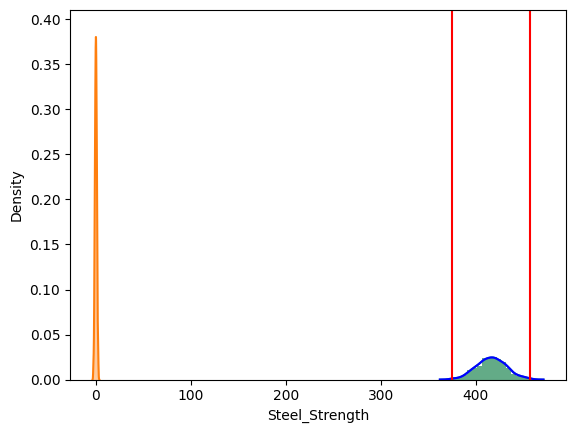

In [48]:
sns.distplot(dataset["Steel_Strength"])

Univariate.get_pdf_probability(
    dataset["Steel_Strength"],
    int(dataset["Steel_Strength"].min()),
    int(dataset["Steel_Strength"].max())
)

Univariate.stdNBgraph(dataset["Steel_Strength"])